<a href="https://colab.research.google.com/github/SANGRAMLEMBE/100_days_of_ML/blob/main/Day36_Handling_Missing_Data/Arbitrary_Value_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [50]:
df  = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [52]:
df.isnull().mean()  # percentage of missing data

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [53]:
x = df.drop(columns = ['Survived'])

In [54]:
y = df['Survived']

In [55]:
x_train , x_test, y_train , y_test = train_test_split(x,y,test_size=0.2, random_state = 2)


In [56]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [57]:
x_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [58]:
# mean_age = x_train['Age'].mean()
# median_age = x_train['Age'].median()
# mode_age = x_train['Age'].mode()

# mean_fare = x_train['Fare'].mean()
# median_fare = x_train['Fare'].median()
# mode_fare = x_train['Fare'].mode()

In [59]:
x_train['Age_99'] = x_train['Age'].fillna(99)
x_train['Age_minus1'] = x_train['Age'].fillna(-1)

x_train['Fare_999'] = x_train['Fare'].fillna(999)
x_train['Fare_minus1'] = x_train['Fare'].fillna(-1)

In [60]:
x_train.sample(10)

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
53,29.0,26.0000,1,29.0,29.0,26.0000,26.0000
71,16.0,46.9000,7,16.0,16.0,46.9000,46.9000
817,31.0,37.0042,2,31.0,31.0,37.0042,37.0042
524,NaN,7.2292,0,99.0,-1.0,7.2292,7.2292
714,52.0,13.0000,0,52.0,52.0,13.0000,13.0000
580,25.0,30.0000,2,25.0,25.0,30.0000,30.0000
130,33.0,7.8958,0,33.0,33.0,7.8958,7.8958
60,22.0,7.2292,0,22.0,22.0,7.2292,7.2292
284,NaN,26.0000,0,99.0,-1.0,26.0000,26.0000
804,27.0,6.9750,0,27.0,27.0,6.9750,6.9750


In [61]:
print('Original Age variable variance:', x_train['Age'].var())
print('Age imputed with median variance:', x_train['Age_99'].var())
print('Age imputed with mean variance:', x_train['Age_minus1'].var())

print('Original fare variable varience', x_train['Fare'].var())
print('Fare imputed with median variance:', x_train['Fare_999'].var())
print('Fare imputed with mean variance:', x_train['Fare_minus1'].var())

Original Age variable variance: 204.3495133904614
Age imputed with median variance: 951.7275570187172
Age imputed with mean variance: 318.0896202624484
Original fare variable varience 2448.197913706318
Fare imputed with median variance: 47219.20265217623
Fare imputed with mean variance: 2378.5676784883503


## Here we getting drastic change at mean , because of we added mean values at missing value which is problimatic as it showing much difference

<Axes: ylabel='Density'>

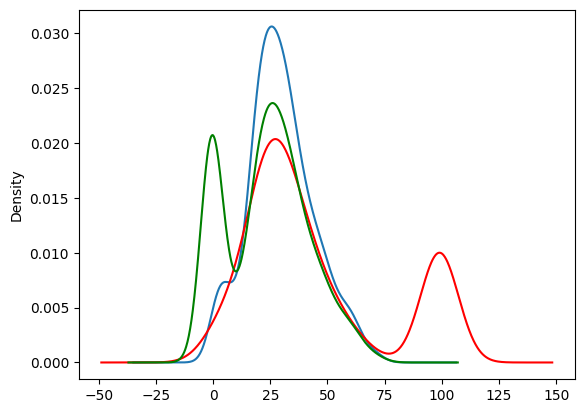

In [62]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind = 'kde', ax = ax)
x_train['Age_99'].plot(kind = 'kde', ax = ax, color = 'red')
x_train['Age_minus1'].plot(kind = 'kde', ax = ax, color = 'green')

# Here we can see nearly all curves are same

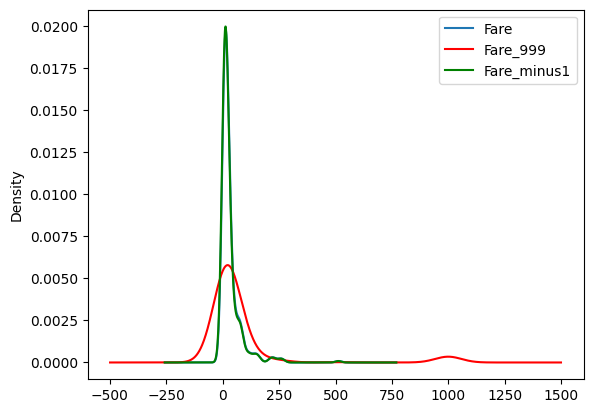

In [63]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable distribution
x_train['Fare'].plot(kind = 'kde', ax = ax)

# Variable Imputed with the median
x_train['Fare_999'].plot(kind = 'kde', ax = ax, color = 'red')

# variable imputed with mean
x_train['Fare_minus1'].plot(kind = 'kde', ax = ax, color = 'green')

# add Legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc = 'best')

In [64]:
# Covariance

x_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [65]:
x_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


#Boxplot

## we can see without mean and median we don't have too much Outliers , but in mean and median we can see clearly soo many outliers

- This is not GOOD ---> RED Flag 🚩

<Axes: >

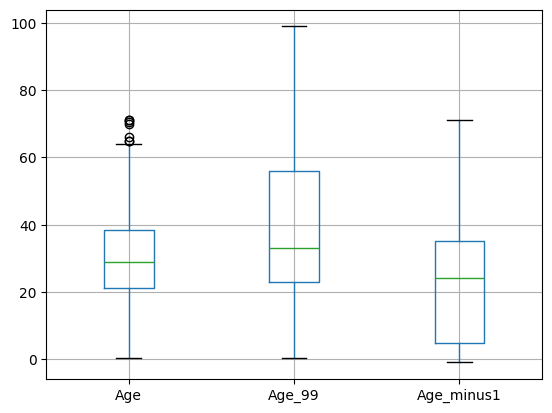

In [67]:
x_train[['Age','Age_99','Age_minus1']].boxplot()

# Outliers are looks same in all the cases , mean is not derivats much from original


Green Flag 🚩

<Axes: >

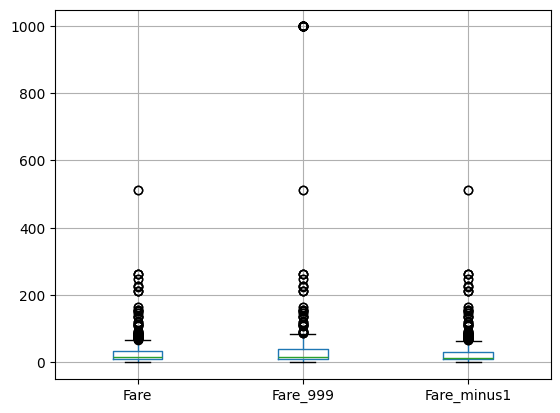

In [68]:
x_train[['Fare','Fare_999','Fare_minus1']].boxplot()

# Using Sklearn

In [70]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)


In [71]:
imputer1 = SimpleImputer(strategy = 'constant', fill_value=99)
imputer2 = SimpleImputer(strategy = 'constant', fill_value=999)



In [80]:
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder = 'passthrough')

In [81]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=999,
                                               strategy='constant'),
                                 ['Fare'])])

In [82]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [83]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [84]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [85]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])